In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# fake_bills.csv 파일을 구분자(;) 기준으로 읽어와 데이터프레임으로 저장
df = pd.read_csv('/content/fake_bills.csv', sep=';')
# 데이터프레임의 상위 5개 행을 출력하여 데이터 내용 확인
df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [83]:
# 'is_genuine' 컬럼을 원-핫 인코딩하여 가짜/진짜 지폐 여부를 숫자형 더미 변수로 변환
# 예: 'is_genuine' 값이 'True' 또는 'False'라면 → 두 개의 컬럼(True, False) 생성
one_hot_encoded = pd.get_dummies(df['is_genuine'])

# 기존의 'is_genuine' 컬럼은 더 이상 필요 없으므로 데이터프레임에서 제거
df.drop('is_genuine', axis=1, inplace=True)

# 기존 df와 원-핫 인코딩 결과를 열 방향으로 병합 (가짜/진짜 구분 열 추가)
df = pd.concat([df, one_hot_encoded], axis=1)

print(df)


      diagonal  height_left  height_right  margin_low  margin_up  length  \
0       171.81       104.86        104.95        4.52       2.89  112.83   
1       171.46       103.36        103.66        3.77       2.99  113.09   
2       172.69       104.48        103.50        4.40       2.94  113.16   
3       171.36       103.91        103.94        3.62       3.01  113.51   
4       171.73       104.28        103.46        4.04       3.48  112.54   
...        ...          ...           ...         ...        ...     ...   
1495    171.75       104.38        104.17        4.42       3.09  111.28   
1496    172.19       104.63        104.44        5.27       3.37  110.97   
1497    171.80       104.01        104.12        5.51       3.36  111.95   
1498    172.06       104.28        104.06        5.17       3.46  112.25   
1499    171.47       104.15        103.82        4.63       3.37  112.07   

      False   True  
0     False   True  
1     False   True  
2     False   True  
3  

In [84]:
# 데이터프레임 내 결측치 여부를 True/False로 나타내는 동일 크기의 DataFrame 생성
# 각 원소가 결측치(NaN)일 경우 True, 아니면 False
missing_values = df.isna()

# 각 컬럼별 결측치 개수를 계산 (True의 합을 구함)
num_missing = missing_values.sum()

# 컬럼별 결측치 개수를 출력
print(num_missing)


diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
False            0
True             0
dtype: int64


<Axes: >

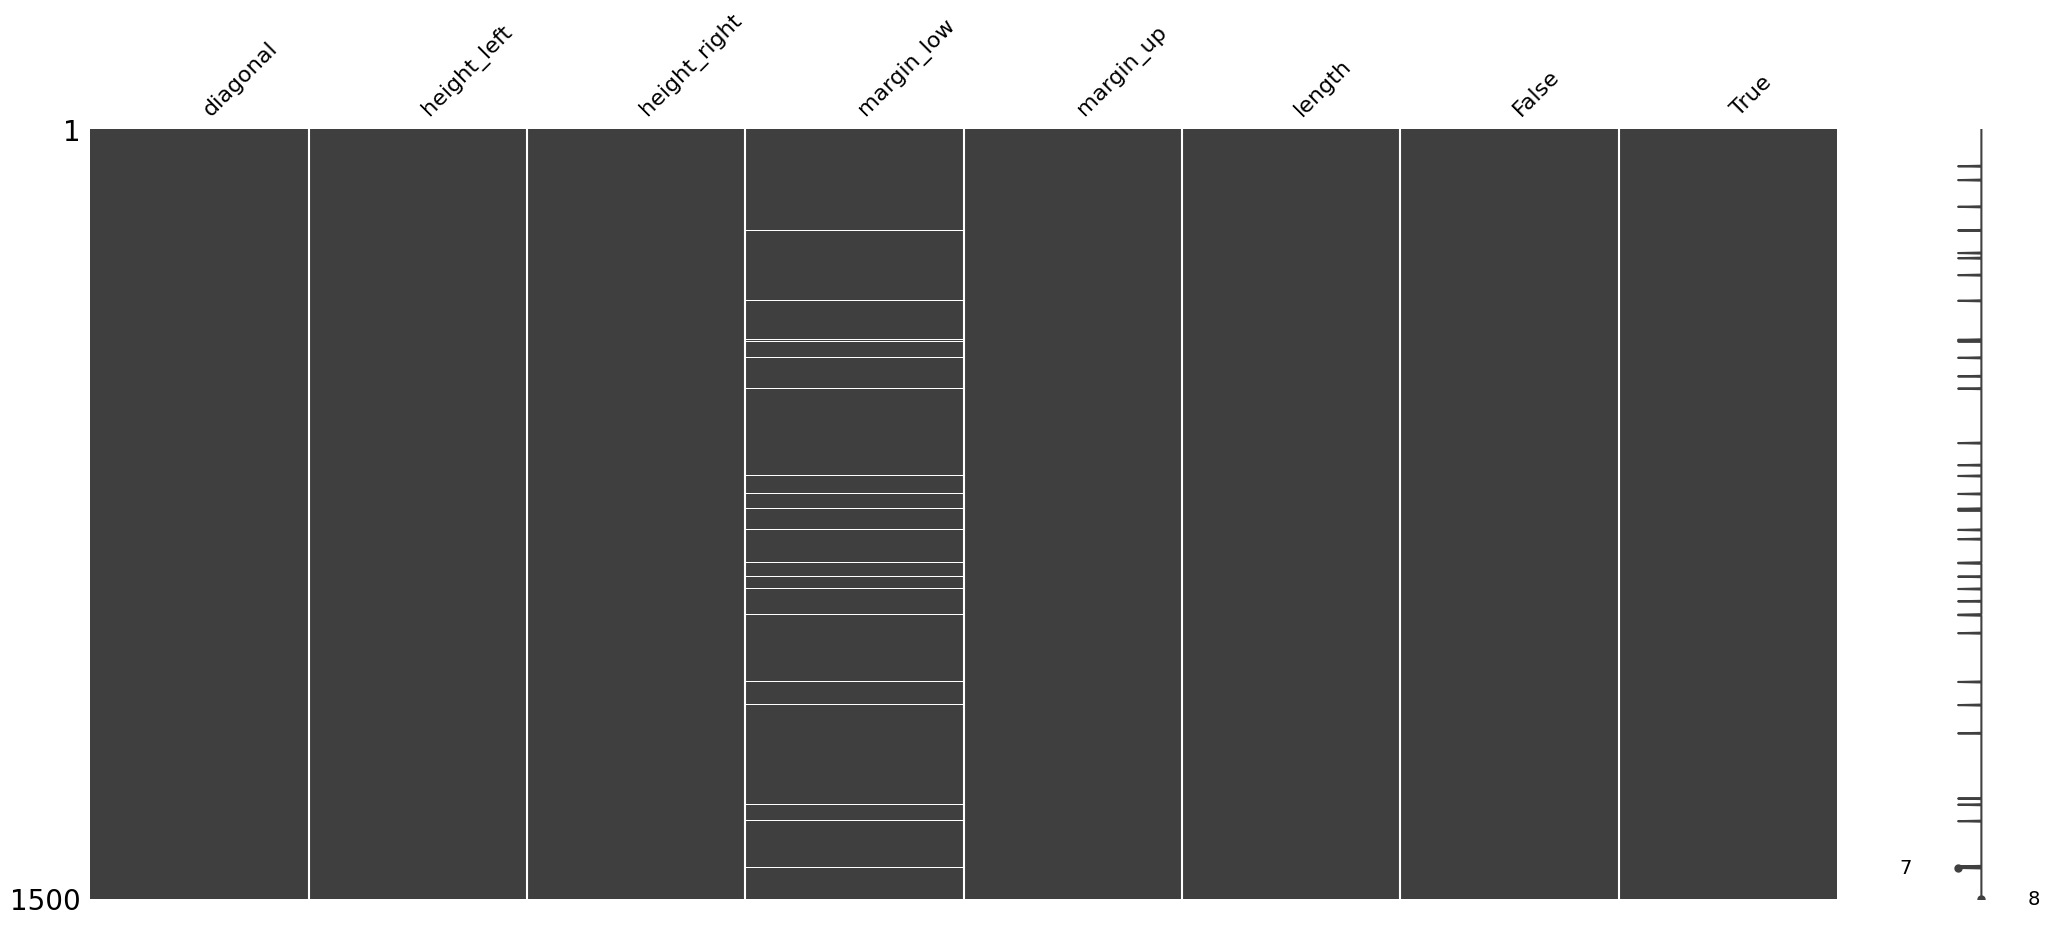

In [85]:
# missingno 라이브러리를 이용해 결측치 분포를 시각적으로 확인
# 각 컬럼별 결측치 위치를 수직 막대 그래프로 표시
# 데이터가 비어 있지 않은 경우는 흰색, 결측치가 있는 경우는 회색으로 나타남

msno.matrix(df)


<Axes: >

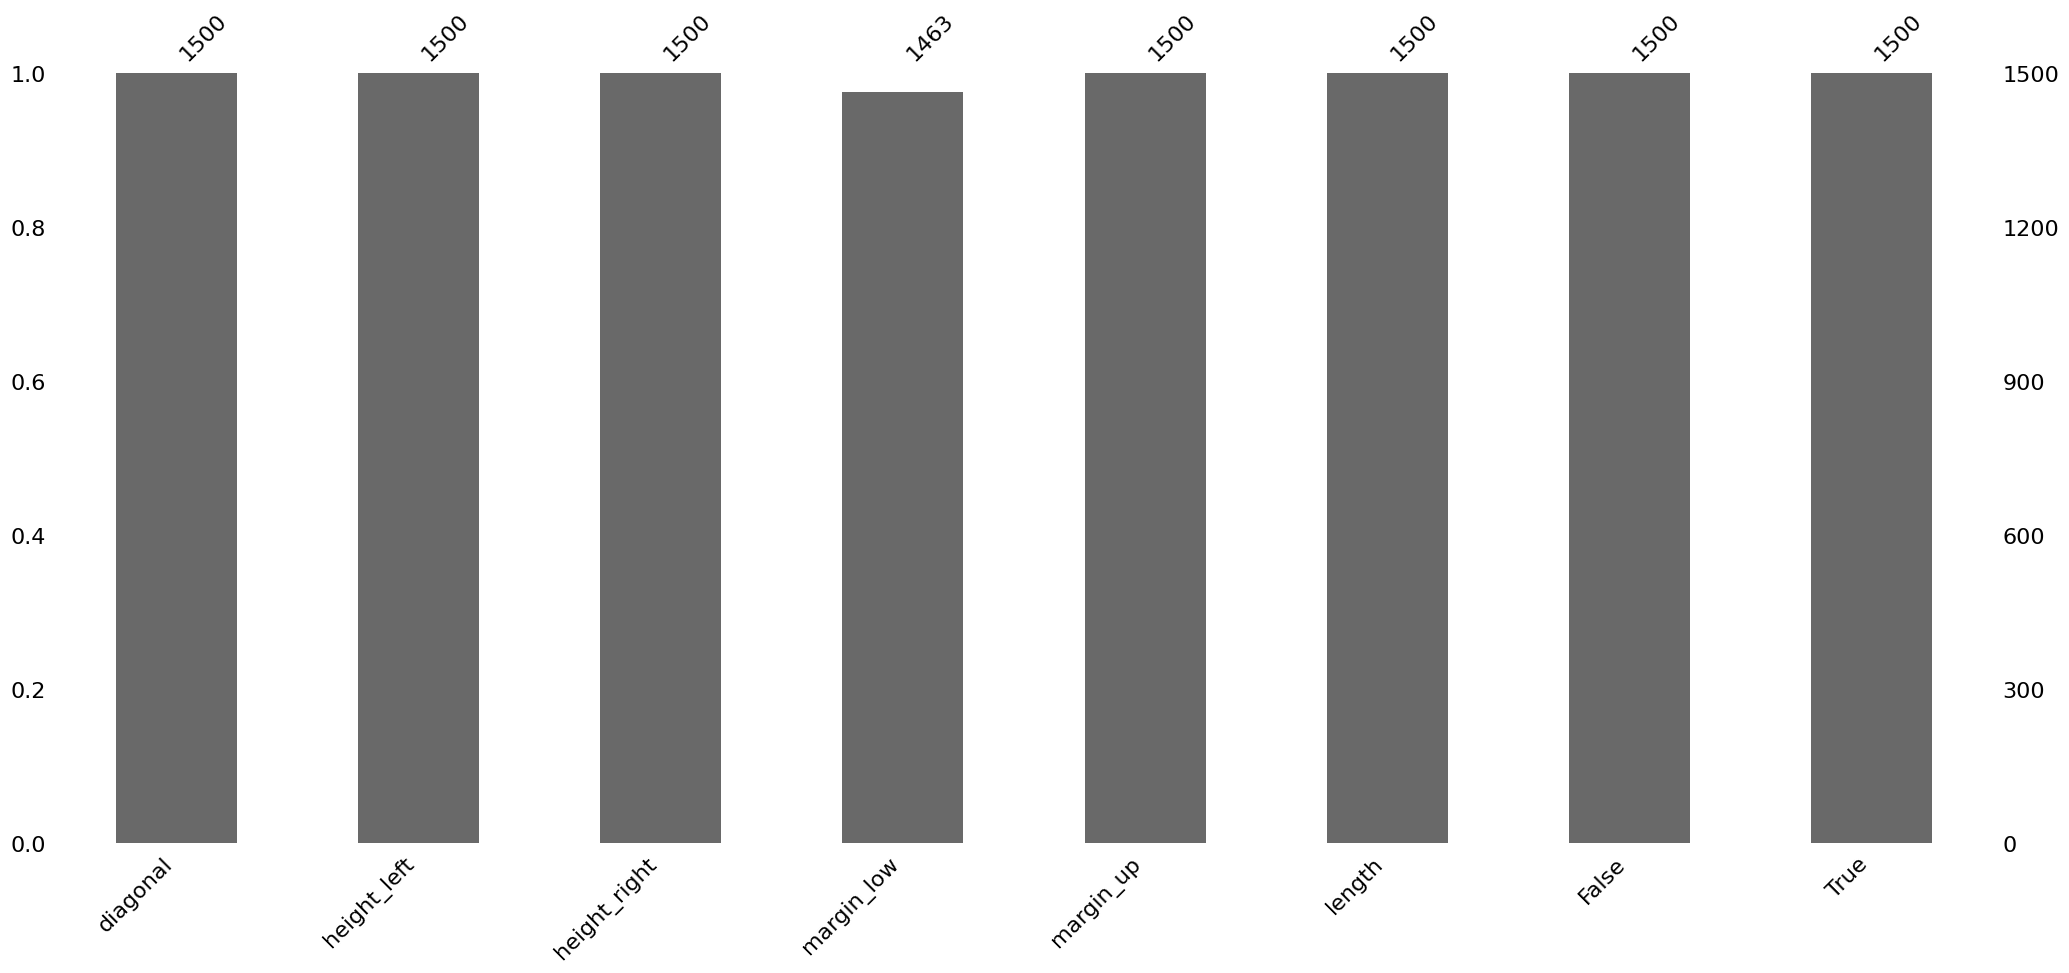

In [86]:
# missingno 라이브러리의 bar() 함수를 이용해
# 각 컬럼별 결측치 개수를 막대그래프로 시각화

msno.bar(df)


In [87]:
# KNNImputer 객체 생성 (결측치를 채울 때 사용할 이웃의 수 = 5)
imputer = KNNImputer(n_neighbors=5)

# 'margin_low' 컬럼에 대해 KNN 기반 결측치 대체 수행
# 결측치가 있는 행은 가장 가까운 5개 이웃의 평균값으로 채워짐
filled_values = imputer.fit_transform(df[['margin_low']])

# 대체된 결과를 원래의 'margin_low' 컬럼에 다시 할당 (DataFrame → ndarray 이므로 직접 덮어씌움)
df['margin_low'] = filled_values

# 전체 데이터프레임에 대해 결측치가 남아있는지 확인
missing_values = df.isna()

# 각 컬럼별 결측치 개수를 다시 계산
num_missing = missing_values.sum()

print(num_missing)

diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
False           0
True            0
dtype: int64


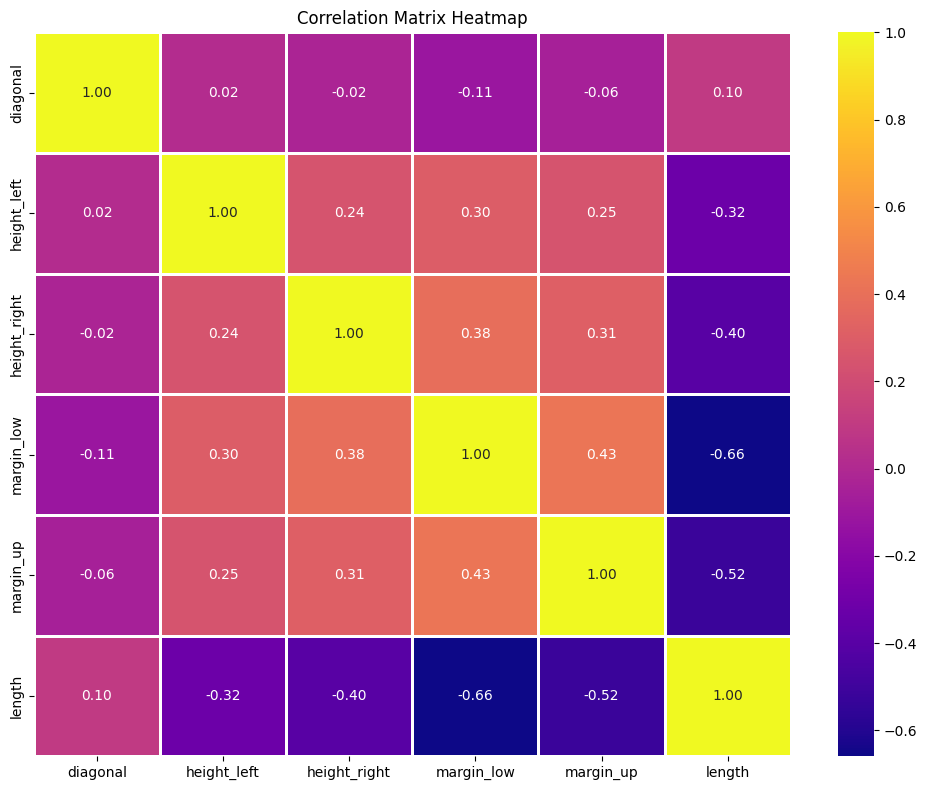

In [88]:
# 수치형(numeric) 데이터만 선택 (예: float, int 등)
# 상관계수 분석은 수치형 데이터에만 적용 가능하므로 필요함
numeric_df = df.select_dtypes(include=[np.number])

# 선택된 수치형 데이터의 열 간 상관계수 행렬을 계산 (피어슨 상관계수 기준)
# np.corrcoef는 각 열(column)을 변수로 간주하므로 transpose(.T) 필요
corr_matrix = np.corrcoef(numeric_df.values.T)

# 시각화: 그래프 사이즈 설정 (가로 10, 세로 8 인치)
plt.figure(figsize=(10, 8))

# seaborn을 이용한 상관계수 히트맵 그리기
sns.heatmap(
    corr_matrix,               # 상관계수 행렬 입력
    linewidth=1,               # 셀 경계선 두께
    cmap='plasma',             # 색상 맵: 'plasma'는 따뜻한 계열의 컬러
    xticklabels=numeric_df.columns,  # x축 라벨: 원래 변수명
    yticklabels=numeric_df.columns,  # y축 라벨: 원래 변수명
    annot=True,                # 셀 안에 수치값 표기
    fmt=".2f"                  # 소수점 둘째 자리까지 표시
)

# 히트맵 제목 설정
plt.title("Correlation Matrix Heatmap")

# 레이아웃 자동 조정 (라벨이 겹치지 않도록)
plt.tight_layout()

# 시각화된 히트맵 출력
plt.show()



In [89]:
# 표준화(정규화)를 적용할 수치형 컬럼 목록 지정
# 이 변수들은 단위/크기가 다를 수 있으므로 모델 학습 전에 스케일을 맞춰주는 것이 중요
numeric_columns = ['margin_low', 'margin_up', 'length',
                   'height_right', 'height_left', 'diagonal']

# StandardScaler는 평균 0, 표준편차 1로 스케일을 맞춰주는 정규화 도구
scaler = StandardScaler()

# 지정한 수치형 컬럼들에 대해 fit_transform()을 적용하여 표준화 수행
# 반환된 결과는 ndarray이므로 원래의 df 컬럼에 덮어씌움
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

# 스케일링 후 결과 확인을 위해 상위 5개 행 출력
print(df.head())


   diagonal  height_left  height_right  margin_low  margin_up    length  \
0 -0.486540     2.774123      3.163240    0.051931  -1.128325  0.173651   
1 -1.633729    -2.236535     -0.799668   -1.092495  -0.696799  0.471666   
2  2.397823     1.504756     -1.291191   -0.131177  -0.912562  0.551901   
3 -1.961498    -0.399294      0.060498   -1.321380  -0.610494  0.953075   
4 -0.748754     0.836669     -1.414072   -0.680502   1.417677 -0.158750   

   False  True  
0  False  True  
1  False  True  
2  False  True  
3  False  True  
4  False  True  


In [90]:
print(df.info())
print( df.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   diagonal      1500 non-null   float64
 1   height_left   1500 non-null   float64
 2   height_right  1500 non-null   float64
 3   margin_low    1500 non-null   float64
 4   margin_up     1500 non-null   float64
 5   length        1500 non-null   float64
 6   False         1500 non-null   bool   
 7   True          1500 non-null   bool   
dtypes: bool(2), float64(6)
memory usage: 73.4 KB
None
Index([    'diagonal',  'height_left', 'height_right',   'margin_low',
          'margin_up',       'length',          False,           True],
      dtype='object')


In [91]:
# 컬럼명이 숫자형 타입일 경우를 대비해 문자열(str) 타입으로 변환
df.columns = df.columns.astype(str)

# 입력 변수(X)와 출력 변수(y) 분리
# - 입력: 지폐의 특성(길이, 높이 등)
# - 출력: 위조 여부 (False, True 두 개의 원-핫 인코딩 컬럼)
X = df.drop(['False', 'True'], axis=1)
y = df[['False', 'True']]

# 학습용/테스트용 데이터셋 분리
# - test_size=0.3: 전체 데이터의 30%를 테스트셋으로 사용
# - random_state=42: 랜덤 분할을 재현 가능하게 고정
# - stratify=y: 클래스 비율이 학습셋과 테스트셋에 동일하게 유지되도록 계층적 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.head()

,diagonal,height_left,height_right,margin_low,margin_up,length
1166,-0.224325,0.669647,1.842271,0.174003,-0.006358,-1.992690
1496,0.758981,2.005822,1.596509,1.196357,0.942999,-1.958303
1339,-0.683201,0.435816,0.951385,1.928789,0.425168,-1.144493
1099,-2.518704,0.502625,0.275540,0.509701,0.123100,-1.087182
120,-0.125994,-0.833551,-0.953269,-0.711020,0.684084,0.265348


<Figure size 400x300 with 0 Axes>

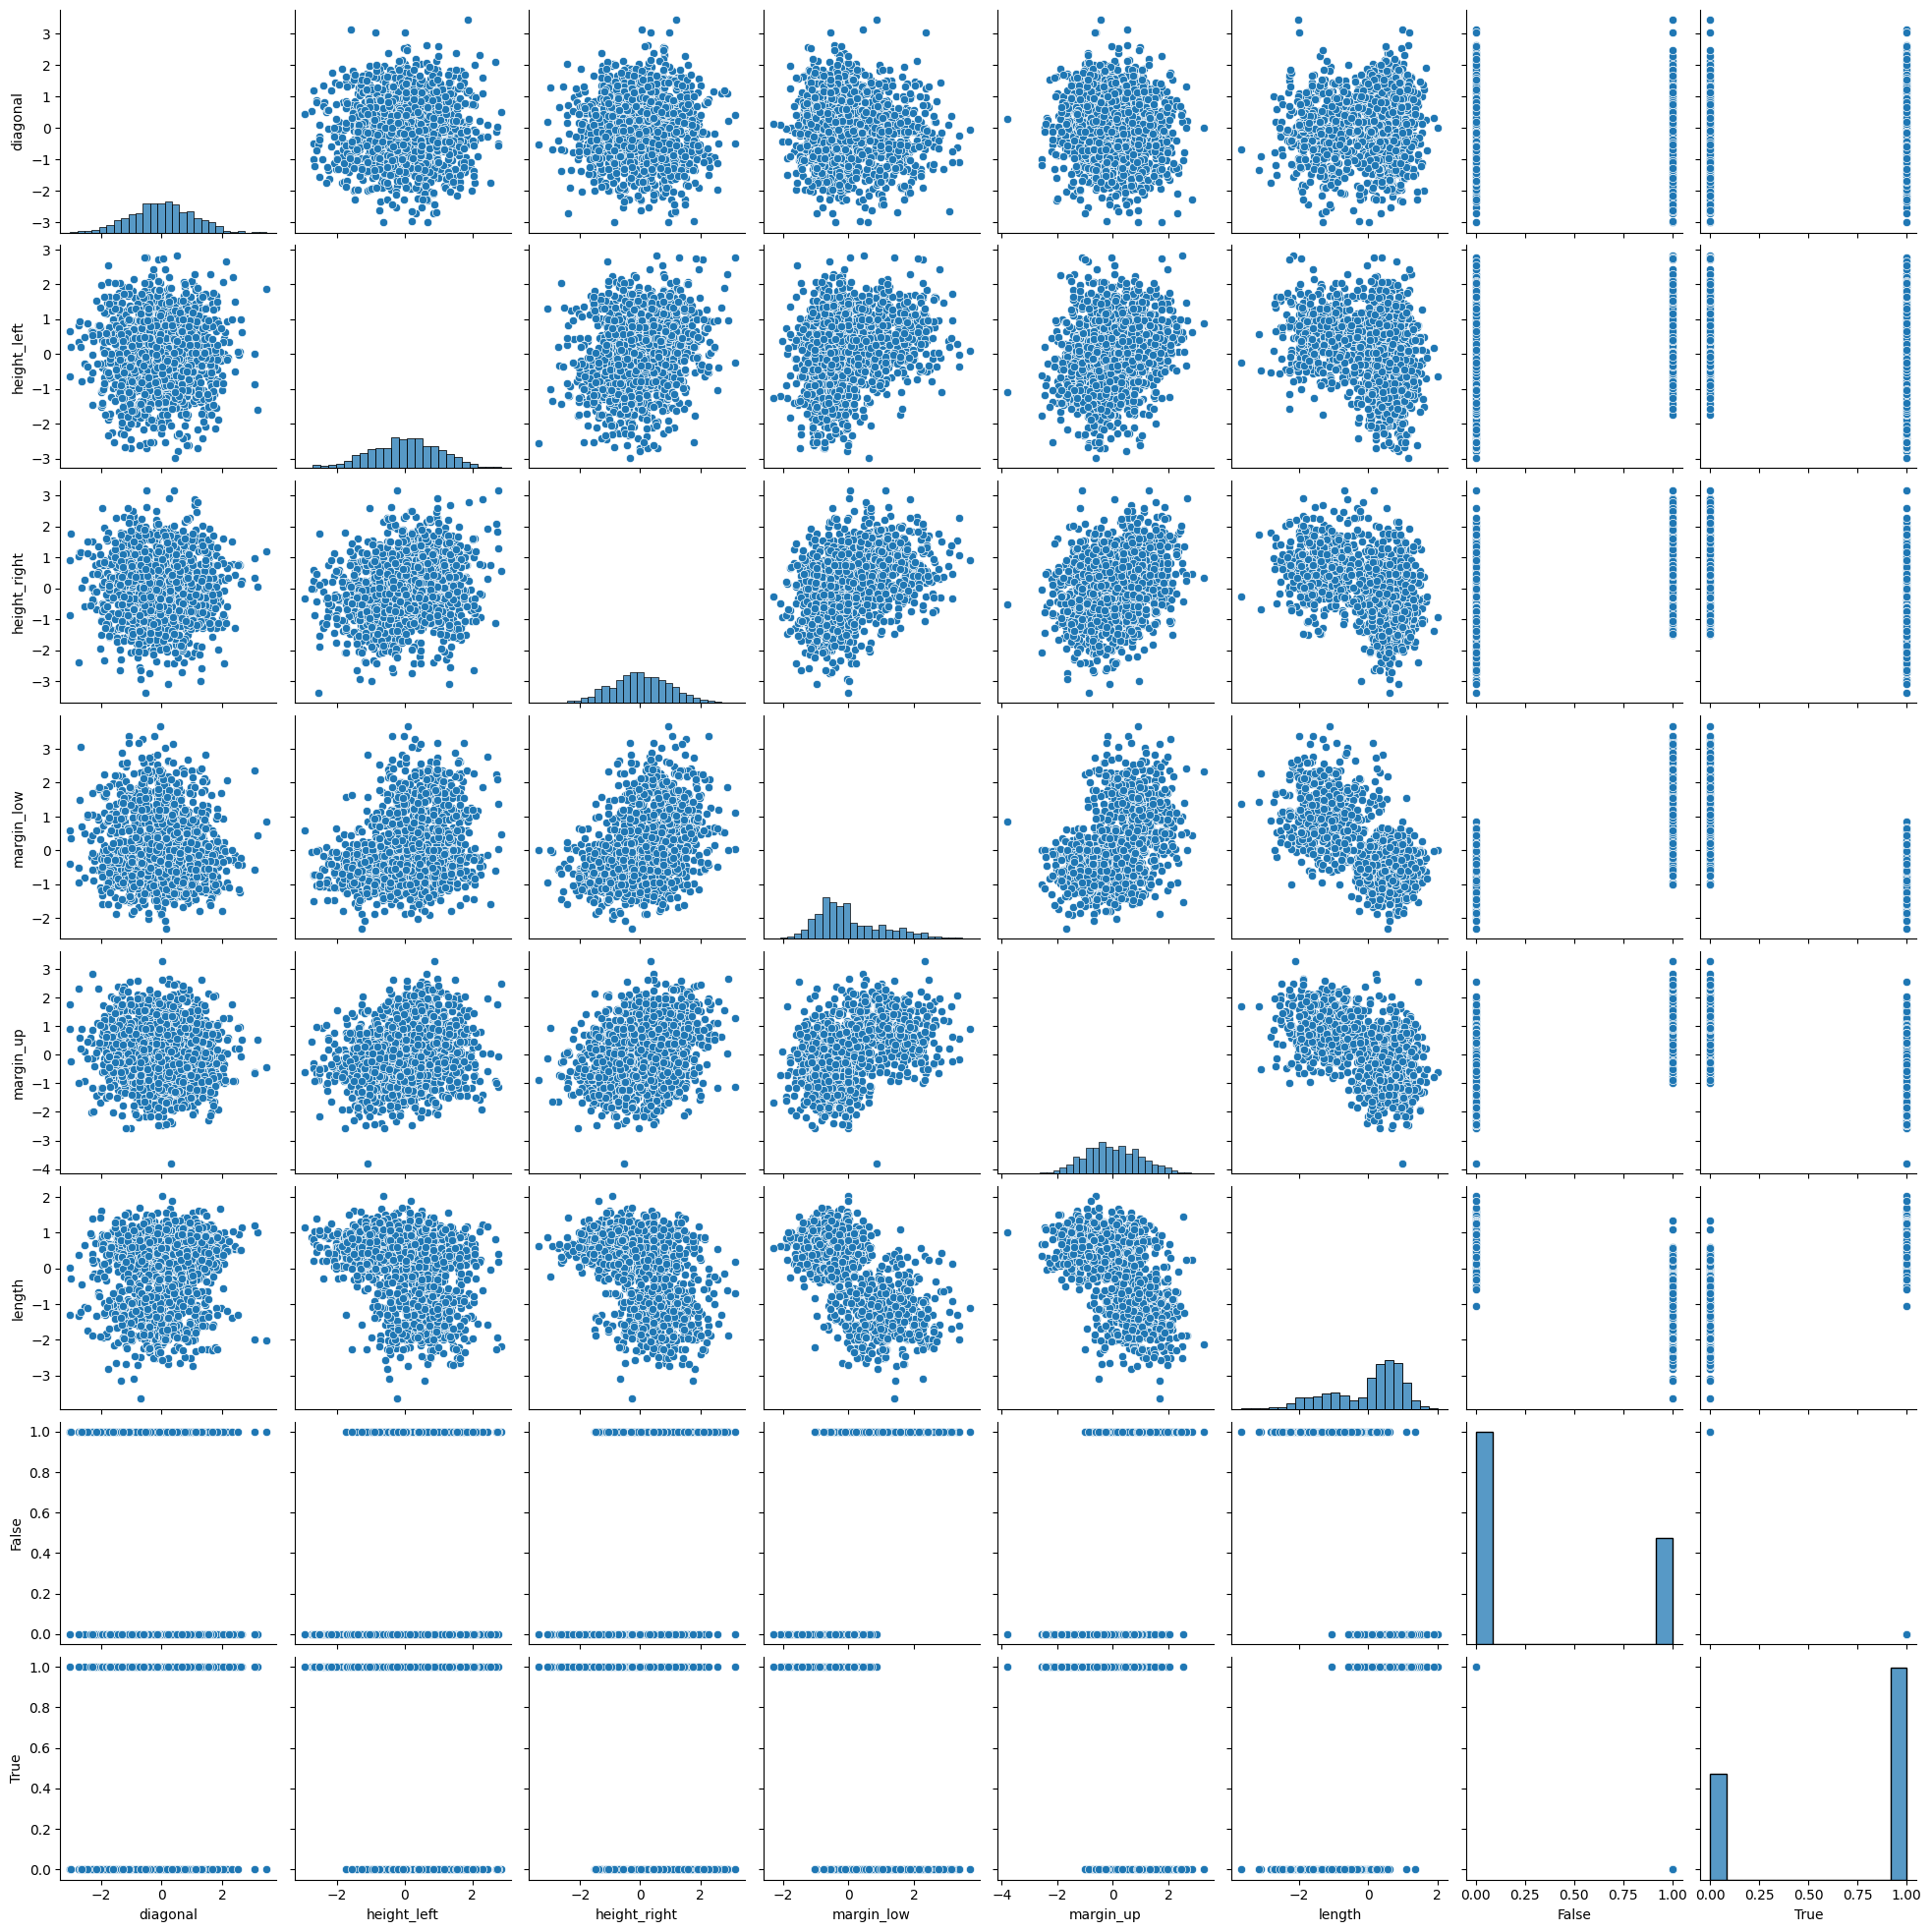

In [92]:
plt.figure(figsize=(4, 3))
sns.pairplot(df)

In [93]:
y_train.head()

,False,True
1166,True,False
1496,True,False
1339,True,False
1099,True,False
120,False,True


In [94]:
y_test.head()

,False,True
1352,True,False
282,False,True
600,False,True
875,False,True
619,False,True


In [95]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# 1. KNN(최근접 이웃 분류기) 모델 객체 생성
# - 거리 기반 분류 알고리즘으로, 이웃 개수(n_neighbors)에 따라 성능이 달라짐
knn_model = KNeighborsClassifier()

# 2. 하이퍼파라미터 탐색을 위한 후보 값 정의
# - n_neighbors 값을 1부터 17까지 홀수로 설정 (짝수는 동점 문제 발생 가능)
param_grid = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17]}

# 3. GridSearchCV 객체 생성
# - 교차검증(cv=10)을 통해 모든 조합의 성능을 비교
# - error_score='raise'는 학습 중 오류 발생 시 예외 발생시킴 (디버깅에 유용)
grid_search = GridSearchCV(knn_model, param_grid, cv=10, error_score='raise')

# 4. 학습 수행
# - 학습 데이터(X_train, y_train)를 기반으로 그리드 서치 실행
grid_search.fit(X_train, y_train)

# 5. 최적의 하이퍼파라미터 및 해당 교차검증 평균 점수 출력
print('Best hyper-parameter:', grid_search.best_params_)        # 가장 성능이 좋았던 n_neighbors 값
print('Best cross-validated score:', grid_search.best_score_)   # 해당 파라미터로 얻은 평균 정확도



Best hyper-parameter: {'n_neighbors': 3}
Best cross-validated score: 0.9914285714285714


In [96]:
from sklearn.metrics import accuracy_score

# KNN 모델 생성 (이웃 수: 3, 거리 기반 가중치 사용)
# weights='distance' → 가까운 이웃일수록 더 큰 영향력을 가짐
model = KNeighborsClassifier(n_neighbors=3, weights='distance')

# 모델 학습 (학습 데이터로 fitting 수행)
model.fit(X_train, y_train)

# 테스트셋에 대한 예측 수행
y_pred = model.predict(X_test)

# 테스트셋 정확도 계산 (예측값과 실제값을 비교하여 정확도 측정)
accuracy = accuracy_score(y_test, y_pred)

# 테스트 정확도 출력
print('Test Accuracy:', accuracy)


Test Accuracy: 0.9888888888888889
